## Module 4: *(Template)*

## Team Members:
Jack Marchesi, Kaitlyn Cole

## Project Title:
Immunoresistance and Angiogenesis in Lung Adenocarcinoma



## Project Goal:
This project seeks to analyze the relation of Immunoresistance and Angiogenesis RNA sequence data to stages of Lung Adenocarcinoma

## Disease Background:
Hallmark Overview

The cancer hallmarks we will be focusing on are both immunoresistance and angiogenesis.    
* Immunoresistance: 
    * Immunoresistance refers to the ability of cancer cells to evade the immune system, preventing immune surveillance from detecting and destroying tumor cells. This hallmark allows tumor to persist and grow, despite the body’s natural defense mechanisms.

    * Genes associated with immunoresistance can be cytotic T lymphocytes (CTLs) as they are the final step of immune regulation in terms of killing tumor cells. Specifically, CTLA4 which is a immune checkpoint which acts as a brake for T cell activity. Additionally, markers such as PD-1 and PD-L1 which are proteins that also downregulate the immune system by sending inhibitory signals to T cells. 

* Angiogenesis:
    * Angiogenesis is when new blood vessels form from pre-existing vasculature which is crucial in embryonic development, wound healing, and tumor growth. It begins with the activation of endothelial cells which can proliferate, migrate and remodel to form sprouts. These sprouts then extend towards the stimulus. In addition, proteolytic enzymes degrade the extracellular matrix to further allow for endothelial migration and invasion into tissue. 

    * Genes associated with angiogenesis are mainly the vascular endothelial growth factor (VEGF) genes. Dysregulated VEGF signals drive tumor angiogenesis. An excess amount of this activity promotes tumor growth while a lack of it leads to impaired wound healing. Other genes that play a role in angiogenesis that can be studied are FGF2 and HIF-1α. 

Lung Adenocarcinoma Disease Background

* Prevalence & incidence
    * Lung adenocarcinoma is the most common subtype of non-small lung cancer (NSCLC), making up for 40-50% of all lung cancer. It currently has the highest number of deaths compared to other cancers for both men and women.
* Risk factors (genetic, lifestyle) & Societal determinants
    * There are genetic and lifestyle factors as well as societal determinants that contribute to lung adenocarcinoma. Genetic factors such as mutations in genes like EFGR, KRAS, and ALK are commonly seen in this type of cancer. These mutations can also impact responses to treatment. The biggest lifestyle factor is smoking. Nonsmokers can develop this cancer, but more often due to genetic factors or other environmental causes. In terms of social determinates, access to healthcare plays a role in early detection and possible treatment which can both impact survival rates.
* Symptoms
    * This type of cancer doesn’t have any symptoms, especially early on. A computed tomography (CT) scan is the only way to screen for this lung cancer. Screening is suggested for individuals between 50 and 80, who have been a heavy smoker, or are currently smoking. This test checks for adenocarcinoma by looking for changes in the lung. In general, lung cancer can have specific symptoms such as upper back pain, shortness of breath, wheezing, and coughing up blood. Advanced stage signs can be problems swallowing and other significant upper respiratory issues.  
* Standard of care treatments (& reimbursement)
    * The treatment depends on the stage of adenocarcinoma and the DNA changes in the specific cancer cells. Surgery is seen in early stages such as stage I or II. This can either be a lobectomy which is a complete resection of one lobe of lung or a segmentectomy which is a small part of the lung. If the cancer is advanced, it may need chemotherapy to shrink before surgery for removal. Another option is radiation, which is normally seen after surgery if the entire tumor wasn’t entirely removable. 
    * In terms of reinbursement that is very much dependant on healthcare. Normally, insurances cover the very standard treatment. This meaning that targeted therapies can be very expensive, thereby limiting the people who have acess to it. 
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)
    * Lung adneocarcinoma starts in the alveolar cells in the lung and normally forms a tumor. It can then metastesize and spread to other areas like the brain, bone, and liver. It can arise from genetic mutations in oncogenes such as EGFG and KRAS, changes in cell signaling, immune envasion, and angiogenesis. More specifically, it starts with the disruption of normal tissue function, an inhibition of immune response, the formation of new blood vessels, metastesis to other organs, and metabolic reprograming of tumor cells. These processes facilitate unchecked tumor growth, metastesis, and and resisatce to treatments. 


## Data-Set: 

We will analyze the predictive effectiveness of immunoresistance and angiogenesis on Lung Adenocarcinoma. This cancer type matches to data under the cancer_type column labeled LUAD. In our data, all of our analyzed genes match to the patients, with 80 total patients in the date with Lung Adenocarcinoma. The genome data comes in units of log2(TPM), where TPM means transcriptions per million. Additionally, the metadata file contains infomation about the patients stage of diagnosis, such as ajcc_pathologic_tumor_stage, ajcc_nodes_pathologic_pn, ajcc_metastasis_pathologic_pm,ajcc_tumor_pathologic_pt, tumor_status, and more. The American Joint Committee on Cancer assigns stages and pathological labels to the patients based on the development of their cancer. The metadata set also contains general informaiton about the patient, such as age of diagnosis and gender. Finally, the metadata contains information about the risk factors that each patient does/doesn't possess. 


The data collection process was discovered by Frederick Sanger in 1977, coined Sanger Sequencing. It starts with RNA isolated from a genome. The RNA is split into short fragments (typically between 200-500 nucleotide base-pairs long), then converted into cDNA. Specific DNA tags are added to the ends of the cDNA sequence, which behave as primers for the sequencing. Using a Next-Generation Sequencer (NGS), the nucleotide sequencing is read, creating huge amounts of raw RNA data. The RNA is matched to known genome sequences and gene expression levels can be determined.

Data investigation below.

In [12]:
# # Loading the files and exploring the data with pandas and sklearn
# %%
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer


# %%
# Load the data
####################################################
data = pd.read_csv(
    'C:\\Users\\Jmarc\\Desktop\\Comp BME\\Module-4-Cancer\\data\\TRAINING_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)  # can also use larger dataset with more genes
metadata_df = pd.read_csv(
    'C:\\Users\\Jmarc\\Desktop\\Comp BME\\Module-4-Cancer\\data\\TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)
print(data.head())
gene_list = pd.read_csv(r'C:\Users\Jmarc\Desktop\Comp BME\Module-4-Cancer\Menyhart_JPA_CancerHallmarks_core.txt', sep='\t', header=None, index_col=0)


        TCGA-E9-A1NI-01A-11R-A14D-07  TCGA-E2-A1LK-01A-21R-A14D-07  \
A1BG                        3.397369                      3.466089   
A1CF                        0.008857                      0.039562   
A2M                         7.575125                      6.643613   
A2ML1                       0.397610                      7.625124   
A4GALT                      5.277425                      5.244677   

        TCGA-BH-A0B2-01A-11R-A10J-07  TCGA-E2-A107-01A-11R-A10J-07  \
A1BG                        3.789771                      3.967578   
A1CF                        0.065051                      0.000000   
A2M                         9.024479                      7.573842   
A2ML1                       0.428689                      0.465410   
A4GALT                      4.072650                      4.208381   

        TCGA-LL-A5YN-01A-11R-A28M-07  TCGA-BH-A0DQ-01A-11R-A084-07  \
A1BG                        4.733007                      3.011343   
A1CF              

        TCGA-E9-A1NI-01A-11R-A14D-07  TCGA-E2-A1LK-01A-21R-A14D-07  \
A1BG                        3.397369                      3.466089   
A1CF                        0.008857                      0.039562   
A2M                         7.575125                      6.643613   
A2ML1                       0.397610                      7.625124   
A4GALT                      5.277425                      5.244677   

        TCGA-BH-A0B2-01A-11R-A10J-07  TCGA-E2-A107-01A-11R-A10J-07  \
A1BG                        3.789771                      3.967578   
A1CF                        0.065051                      0.000000   
A2M                         9.024479                      7.573842   
A2ML1                       0.428689                      0.465410   
A4GALT                      4.072650                      4.208381   

        TCGA-LL-A5YN-01A-11R-A28M-07  TCGA-BH-A0DQ-01A-11R-A084-07  \
A1BG                        4.733007                      3.011343   
A1CF              

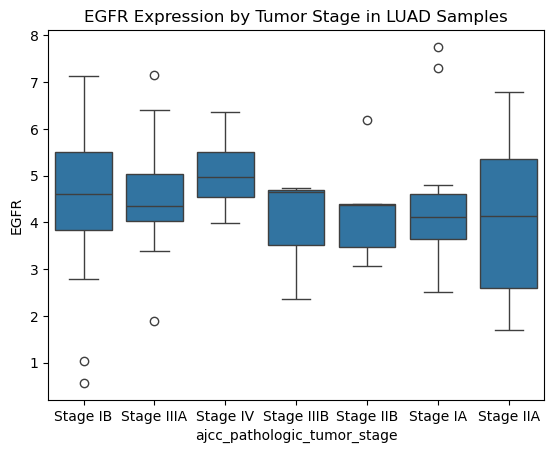

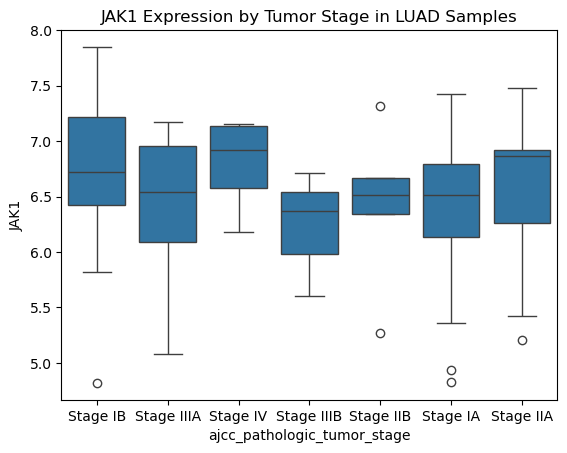

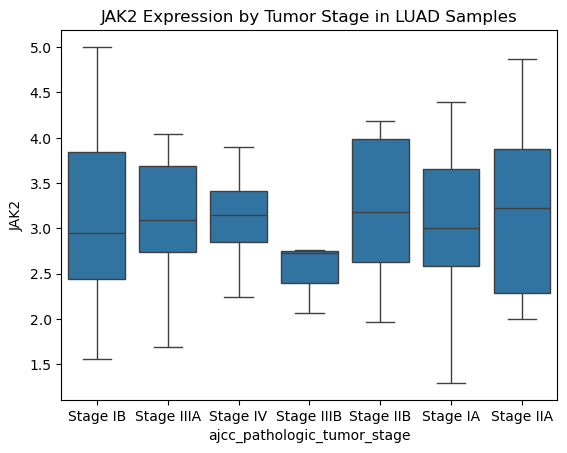

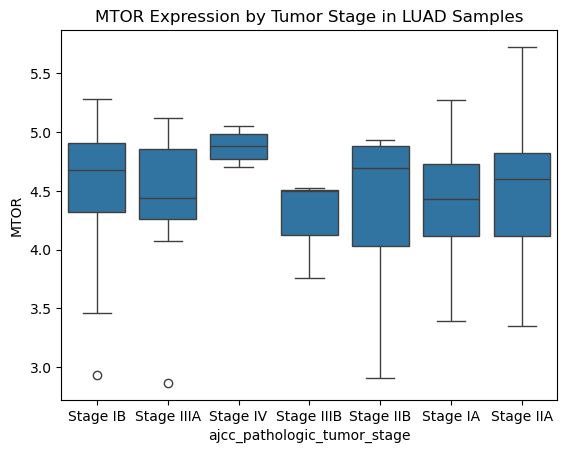

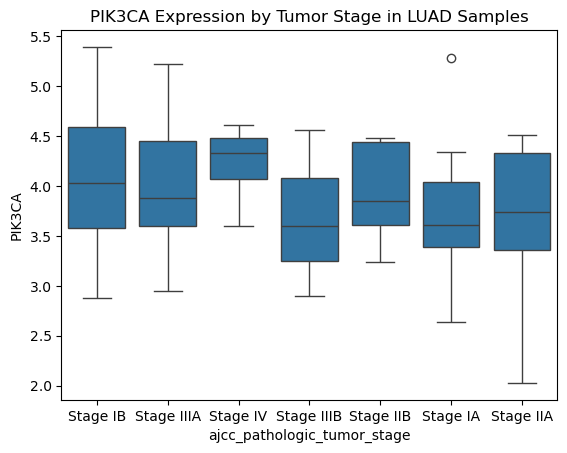

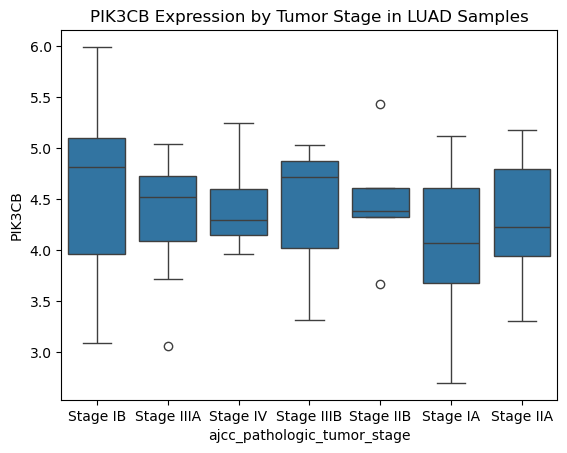

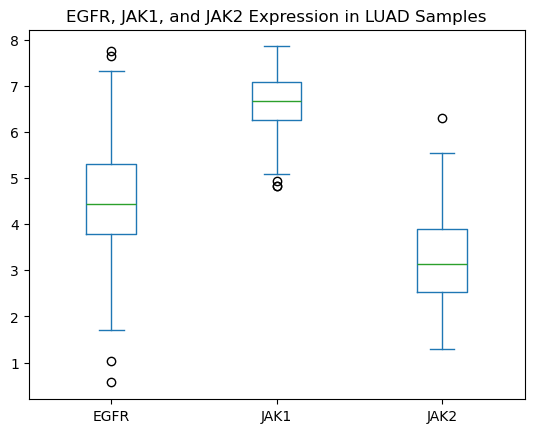

In [ ]:
# Exploratory data analysis (EDA) on a cancer dataset

# %%
# Explore the data
####################################################
print(data.shape)
print(data.info())
print(data.describe())

# %%
# Explore the metadata
####################################################
print(metadata_df.info())
print(metadata_df.describe())

# %%
# Subset the data for a specific cancer type
####################################################
cancer_type = 'LUAD'  # Lung Adenocarcinoma

# From metadata, get the rows where "cancer_type" is equal to the specified cancer type
# Then grab the index of this subset (these are the sample IDs)
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
print(cancer_samples)
# Subset the main data to include only these samples
# When you want a subset of columns, you can pass a list of column names to the data frame in []
LUAD_data = data[cancer_samples]

# %%
# Subset by index (genes)
####################################################
desired_gene_list = ['EGFR', 'JAK1', 'JAK2', 'MTOR', 'PIK3CA', 'PIK3CB']
gene_list = [gene for gene in desired_gene_list if gene in LUAD_data.index]
for gene in desired_gene_list:
    if gene not in gene_list:
        print(f"Warning: {gene} not found in the dataset.")

# .loc[] is the method to subset by index labels
# .iloc[] will subset by index position (integer location) instead
LUAD_gene_data = LUAD_data.loc[gene_list]
print(LUAD_gene_data.head())

# Check number of data points per gene
gene_summary = pd.DataFrame({
    "non_missing_count": LUAD_gene_data.count(axis=1),
    "missing_count": LUAD_gene_data.isna().sum(axis=1)
})
print("HERE IS THE GENE SUMMARY:")
print(gene_summary)
# %%
# Basic statistics on the subsetted data
####################################################
print(LUAD_gene_data.describe())
print(LUAD_gene_data.var(axis=1))  # Variance of each gene across samples
# Mean expression of each gene across samples
print(LUAD_gene_data.mean(axis=1))
# Median expression of each gene across samples
print(LUAD_gene_data.median(axis=1))

# %%
# Explore categorical variables in metadata
####################################################
# groupby allows you to group on a specific column in the dataset,
# and then print out summary stats or counts for other columns within those groups
print(metadata_df.groupby('cancer_type')["ajcc_pathologic_tumor_stage"].value_counts())

# Explore average age at diagnosis by cancer type
metadata_df['age_at_diagnosis'] = pd.to_numeric(
    metadata_df['age_at_diagnosis'], errors='coerce')
print(metadata_df.groupby(
    'cancer_type')["age_at_diagnosis"].mean())
# %%
# Merging datasets
####################################################
# Merge the subsetted expression data with metadata for LUAD samples,
# so rows are samples and columns include gene expression for EGFR and MYC and metadata
LUAD_metadata = metadata_df.loc[cancer_samples]
LUAD_merged = LUAD_gene_data.T.merge(
    LUAD_metadata, left_index=True, right_index=True)
print(LUAD_merged.head())

# %%
# Plotting
####################################################
# Boxplot of EGFR expression in LUAD samples using SEABORN
# Works really well with pandas dataframes, because most methods allow you to pass in a dataframe directly
sns.boxplot(data=LUAD_merged, x="ajcc_pathologic_tumor_stage", y='EGFR')
plt.title("EGFR Expression by Tumor Stage in LUAD Samples")
plt.show()

sns.boxplot(data=LUAD_merged, x="ajcc_pathologic_tumor_stage", y='JAK1')
plt.title("JAK1 Expression by Tumor Stage in LUAD Samples")
plt.show()

sns.boxplot(data=LUAD_merged, x="ajcc_pathologic_tumor_stage", y='JAK2')
plt.title("JAK2 Expression by Tumor Stage in LUAD Samples")
plt.show()

sns.boxplot(data=LUAD_merged, x="ajcc_pathologic_tumor_stage", y='MTOR')
plt.title("MTOR Expression by Tumor Stage in LUAD Samples")
plt.show()

sns.boxplot(data=LUAD_merged, x="ajcc_pathologic_tumor_stage", y='PIK3CA')
plt.title("PIK3CA Expression by Tumor Stage in LUAD Samples")
plt.show()

sns.boxplot(data=LUAD_merged, x="ajcc_pathologic_tumor_stage", y='PIK3CB')
plt.title("PIK3CB Expression by Tumor Stage in LUAD Samples")
plt.show()

# Boxplot of MYC and EGFR expression in LUAD samples using PANDAS directly
LUAD_merged[['EGFR', 'JAK1', 'JAK2']].plot.box()
plt.title("EGFR, JAK1, and JAK2 Expression in LUAD Samples")
plt.show()

# %%


### UMAP

#### UMAP Analyzing Both Hallmarks Together


In [ ]:
# Pull the immune evasion and angiogenesis gene sets from the hallmarks file by their category name
immune_list = list(gene_list.loc['EVADING IMMUNE DESTRUCTION'])
angio_list  = list(gene_list.loc['SUSTAINED ANGIOGENESIS'])

# Some rows have empty cells due to uneven gene counts — remove those NaN values
immune_list = [g for g in immune_list if pd.notna(g)]
angio_list  = [g for g in angio_list  if pd.notna(g)]

# Combine both gene lists into one master list
all_genes = immune_list + angio_list
print(f"Immune genes: {immune_list}")
print(f"Angiogenesis genes: {angio_list}")

# %%
# Subset to LUAD + filter to genes present in dataset
# Grab only the LUAD (Lung Adenocarcinoma) samples from the full dataset
cancer_samples = metadata_df[metadata_df['cancer_type'] == 'LUAD'].index
LUAD_data      = data[cancer_samples]
LUAD_metadata  = metadata_df.loc[cancer_samples].copy()

# Keep only the ones that will be in the expression dataset
gene_list_found = [g for g in all_genes if g in LUAD_data.index]
missing_genes   = [g for g in all_genes if g not in LUAD_data.index]
print(f"\nGenes found in dataset: {len(gene_list_found)}")
print(f"Genes missing from dataset: {missing_genes}")

# Tumor stages come in sub-stages like "Stage IA" — simplify them to just Stage I, II, III, IV
def simplify_stage(stage):
    if pd.isna(stage): return None
    s = str(stage)
    if 'IV'  in s: return 'Stage IV'
    if 'III' in s: return 'Stage III'
    if 'II'  in s: return 'Stage II'
    if 'I'   in s: return 'Stage I'
    return None

LUAD_metadata['simple_stage'] = LUAD_metadata['ajcc_pathologic_tumor_stage'].apply(simplify_stage)
# Drop any samples where the stage is unknown
LUAD_metadata_clean = LUAD_metadata.dropna(subset=['simple_stage'])
clean_samples = LUAD_metadata_clean.index

# Subset the expression matrix to our genes and cleaned samples, then flip so samples are rows
LUAD_gene_data = LUAD_data.loc[gene_list_found, clean_samples]
LUAD_merged    = LUAD_gene_data.T.merge(
    LUAD_metadata_clean[['simple_stage']], left_index=True, right_index=True)

# Fill in any missing expression values with the average for that gene, then standardize
# Standardizing puts all genes on the same scale so no single gene dominates the analysis
X = LUAD_merged[gene_list_found].values
X = SimpleImputer(strategy='mean').fit_transform(X)
X_scaled = StandardScaler().fit_transform(X)

stage_labels = LUAD_merged['simple_stage'].values
stage_order  = ['Stage I', 'Stage II', 'Stage III', 'Stage IV']
# Assign a color to each stage for plotting
palette      = {'Stage I': '#4CAF50', 'Stage II': '#2196F3',
                'Stage III': '#FF9800', 'Stage IV': '#F44336'}

# %%
# UMAP
####################################################
# UMAP reduces our many genes down to 2 dimensions so we can plot and visually inspect
# whether samples with similar gene expression naturally group together by tumor stage
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap  = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
# Each dot is one patient sample, colored by their tumor stage
plt.scatter(X_umap[:, 0], X_umap[:, 1],
            c=[list(palette.values())[stage_order.index(s)] for s in stage_labels],
            s=60, alpha=0.8)

# Build a legend manually since we're using plt.scatter instead of seaborn
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=palette[s], label=s) for s in stage_order]
plt.legend(handles=legend_elements, title='Tumor Stage',
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of LUAD Samples\n(Immune Evasion + Angiogenesis Genes)")
plt.tight_layout()
plt.savefig('umap_luad.png', dpi=150, bbox_inches='tight')
plt.show()



#### UMAP Analyzing Hallmarks Seperately 

##### Immunoresistance

In [ ]:

# UMAP — Immune Evasion Genes Only
# Filter down to only the immune evasion genes that were found in the dataset
immune_found = [g for g in immune_list if g in gene_list_found]
X_immune = LUAD_merged[immune_found].values
# Fill missing values and standardize just like before
X_immune = SimpleImputer(strategy='mean').fit_transform(X_immune)
X_immune_scaled = StandardScaler().fit_transform(X_immune)

# Run UMAP using only immune evasion genes to see if they alone can separate tumor stages
reducer_immune = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap_immune  = reducer_immune.fit_transform(X_immune_scaled)

plt.figure(figsize=(8, 6))
# Each dot is a patient, colored by their tumor stage
plt.scatter(X_umap_immune[:, 0], X_umap_immune[:, 1],
            c=[list(palette.values())[stage_order.index(s)] for s in stage_labels],
            s=60, alpha=0.8)
legend_elements = [Patch(facecolor=palette[s], label=s) for s in stage_order]
plt.legend(handles=legend_elements, title='Tumor Stage',
           bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of LUAD Samples\n(Immune Evasion Genes Only)")
plt.tight_layout()
plt.savefig('umap_immune.png', dpi=150, bbox_inches='tight')
plt.show()

#### Angiogenesis

In [ ]:
# UMAP — Angiogenesis Genes Only
# Filter down to only the angiogenesis genes that were found in the dataset
angio_found = [g for g in angio_list if g in gene_list_found]
X_angio = LUAD_merged[angio_found].values
# Fill missing values and standardize just like before
X_angio = SimpleImputer(strategy='mean').fit_transform(X_angio)
X_angio_scaled = StandardScaler().fit_transform(X_angio)

# Run UMAP using only angiogenesis genes to see if they alone can separate tumor stages
reducer_angio = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap_angio  = reducer_angio.fit_transform(X_angio_scaled)

plt.figure(figsize=(8, 6))
# Each dot is a patient, colored by their tumor stage
plt.scatter(X_umap_angio[:, 0], X_umap_angio[:, 1],
            c=[list(palette.values())[stage_order.index(s)] for s in stage_labels],
            s=60, alpha=0.8)
legend_elements = [Patch(facecolor=palette[s], label=s) for s in stage_order]
plt.legend(handles=legend_elements, title='Tumor Stage',
           bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of LUAD Samples\n(Angiogenesis Genes Only)")
plt.tight_layout()
plt.savefig('umap_angio.png', dpi=150, bbox_inches='tight')
plt.show()

#### UMAP Conclusion

Our UMAP analysis of immunresistance and angiogenesis gene expression in LUAD samples did not reveal clear clustering by tumor stage. This is seen by distributed colored points broadly across the plot. This suggests that these two gene sets alone (and together) may not capture enough of the transcription variations that distringueshes early from late stage lung andenocarcinoma. This is a biologically meaningful result as it implies tumor stage in LUAD is likely driven by a broader complex set of molecular changes beyond the two hallmarks.

* PCA Visualization

In [13]:

gene_list = pd.read_csv(r'C:\Users\Jmarc\Desktop\Comp BME\Module-4-Cancer\Menyhart_JPA_CancerHallmarks_core.txt', sep='\t', header=None, index_col=0)
print(gene_list)

immune_list = list(gene_list.loc['EVADING IMMUNE DESTRUCTION'])
angio_list  = list(gene_list.loc['SUSTAINED ANGIOGENESIS'])

immune_list = [g for g in immune_list if pd.notna(g)]
angio_list  = [g for g in angio_list  if pd.notna(g)]

all_genes = immune_list + angio_list
print(f"Immune genes: {immune_list}")
print(f"Angiogenesis genes: {angio_list}")

# %%
# Subset to LUAD + filter to genes present in dataset
####################################################
cancer_samples = metadata_df[metadata_df['cancer_type'] == 'LUAD'].index
LUAD_data      = data[cancer_samples]
LUAD_metadata  = metadata_df.loc[cancer_samples].copy()

gene_list_found = [g for g in all_genes if g in LUAD_data.index]
missing_genes   = [g for g in all_genes if g not in LUAD_data.index]
print(f"\nGenes found in dataset: {len(gene_list_found)}")
print(f"Genes missing from dataset: {missing_genes}")

def simplify_stage(stage):
    if pd.isna(stage): return None
    s = str(stage)
    if 'IV'  in s: return 'Stage IV'
    if 'III' in s: return 'Stage III'
    if 'II'  in s: return 'Stage II'
    if 'I'   in s: return 'Stage I'
    return None

LUAD_metadata['simple_stage'] = LUAD_metadata['ajcc_pathologic_tumor_stage'].apply(simplify_stage)
LUAD_metadata_clean = LUAD_metadata.dropna(subset=['simple_stage'])
clean_samples = LUAD_metadata_clean.index

LUAD_gene_data = LUAD_data.loc[gene_list_found, clean_samples]
LUAD_merged    = LUAD_gene_data.T.merge(
    LUAD_metadata_clean[['simple_stage']], left_index=True, right_index=True)

X = LUAD_merged[gene_list_found].values
X = SimpleImputer(strategy='mean').fit_transform(X)
X_scaled = StandardScaler().fit_transform(X)

stage_labels = LUAD_merged['simple_stage'].values
stage_order  = ['Stage I', 'Stage II', 'Stage III', 'Stage IV']
palette      = {'Stage I': '#4CAF50', 'Stage II': '#2196F3',
                'Stage III': '#FF9800', 'Stage IV': '#F44336'}


                                         1       2       3       4       5    \
0                                                                              
TISSUE INVASION AND METASTASIS       ANGPTL3   CXCR4   LAMA4   EFNB1  MAP3K8   
REPROGRAMMING ENERGY METABOLISM        IDH3G   COX6C  PFKFB1    TPI1    PYGL   
REPLICATIVE IMMORTALITY              TERF2IP   TERF2   TERF1  CDKN1B     MIF   
GENOME INSTABILITY                     POLE2    CYCS   PALB2   ATRIP   H2AFX   
RESISTING CELL DEATH                   STAT1   RIPK1    CYCS  MAP3K8    RHOA   
EVADING GROWTH SUPPRESSORS             STAT1   RIPK1  MAP3K8   HDAC4    RHOA   
EVADING IMMUNE DESTRUCTION             STAT1   CXCR4   PTPN6    RHOA   STAT3   
SUSTAINED ANGIOGENESIS                 CXCR4  CXCL13    FLT4    RHOA   TGFB2   
SUSTAINING PROLIFERATIVE SIGNALING     STAT1   RIPK1   CXCR4  MAP3K8    RHOA   
TUMOR-PROMOTING INFLAMMATION        HLA-DRB3   PLCB2    CD8B   PRKCG   MYD88   

                                       

PC1 variance explained: 0.231
PC2 variance explained: 0.132
Total variance explained: 0.362


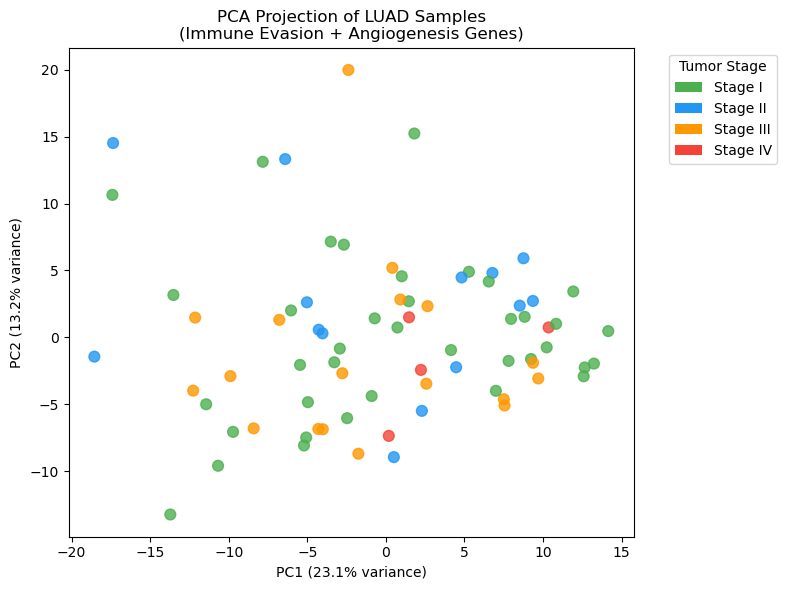

In [14]:

# %%
# PCA — Combined Immune Evasion + Angiogenesis Genes
####################################################
# PCA reduces our many genes down to 2 principal components so we can plot and visually
# inspect whether samples with similar gene expression group together by tumor stage.
# PC1 and PC2 capture the directions of greatest variance in the data.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Print variance explained by each component
print(f"PC1 variance explained: {pca.explained_variance_ratio_[0]:.3f}")
print(f"PC2 variance explained: {pca.explained_variance_ratio_[1]:.3f}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.3f}")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=[list(palette.values())[stage_order.index(s)] for s in stage_labels],
            s=60, alpha=0.8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=palette[s], label=s) for s in stage_order]
plt.legend(handles=legend_elements, title='Tumor Stage',
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA Projection of LUAD Samples\n(Immune Evasion + Angiogenesis Genes)")
plt.tight_layout()
plt.savefig('pca_luad.png', dpi=150, bbox_inches='tight')
plt.show()


Immune PCA — PC1 variance explained: 0.273
Immune PCA — PC2 variance explained: 0.136


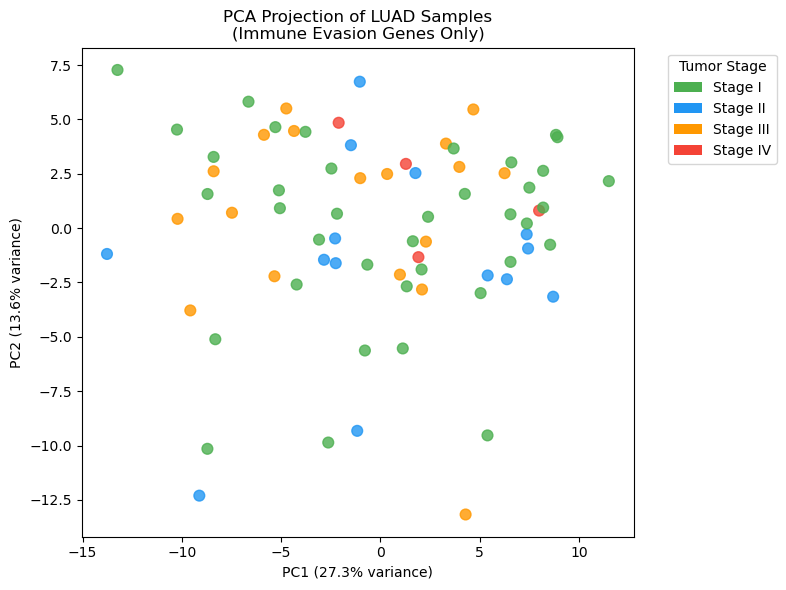

In [17]:

# %%
# PCA — Immune Evasion Genes Only
####################################################
immune_found = [g for g in immune_list if g in gene_list_found]
X_immune = LUAD_merged[immune_found].values
X_immune = SimpleImputer(strategy='mean').fit_transform(X_immune)
X_immune_scaled = StandardScaler().fit_transform(X_immune)

# Limit components to what's feasible given the number of genes
n_components_immune = min(2, len(immune_found))
pca_immune = PCA(n_components=n_components_immune, random_state=42)
X_pca_immune = pca_immune.fit_transform(X_immune_scaled)

print(f"Immune PCA — PC1 variance explained: {pca_immune.explained_variance_ratio_[0]:.3f}")
print(f"Immune PCA — PC2 variance explained: {pca_immune.explained_variance_ratio_[1]:.3f}")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_immune[:, 0], X_pca_immune[:, 1],
            c=[list(palette.values())[stage_order.index(s)] for s in stage_labels],
            s=60, alpha=0.8)
legend_elements = [Patch(facecolor=palette[s], label=s) for s in stage_order]
plt.legend(handles=legend_elements, title='Tumor Stage',
           bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel(f"PC1 ({pca_immune.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_immune.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA Projection of LUAD Samples\n(Immune Evasion Genes Only)")
plt.tight_layout()
plt.savefig('pca_immune.png', dpi=150, bbox_inches='tight')
plt.show()


Angio PCA — PC1 variance explained: 0.221
Angio PCA — PC2 variance explained: 0.108


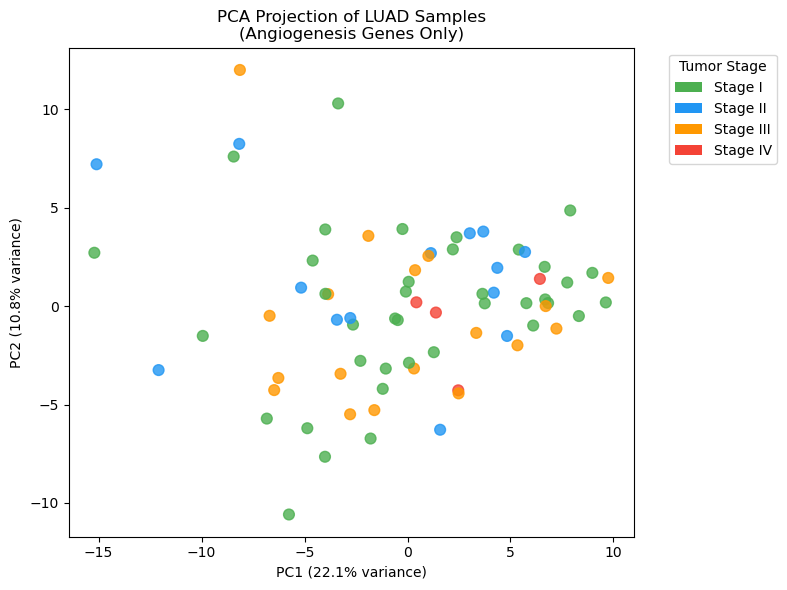

In [16]:

# %%
# PCA — Angiogenesis Genes Only
####################################################
angio_found = [g for g in angio_list if g in gene_list_found]
X_angio = LUAD_merged[angio_found].values
X_angio = SimpleImputer(strategy='mean').fit_transform(X_angio)
X_angio_scaled = StandardScaler().fit_transform(X_angio)

n_components_angio = min(2, len(angio_found))
pca_angio = PCA(n_components=n_components_angio, random_state=42)
X_pca_angio = pca_angio.fit_transform(X_angio_scaled)

print(f"Angio PCA — PC1 variance explained: {pca_angio.explained_variance_ratio_[0]:.3f}")
print(f"Angio PCA — PC2 variance explained: {pca_angio.explained_variance_ratio_[1]:.3f}")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_angio[:, 0], X_pca_angio[:, 1],
            c=[list(palette.values())[stage_order.index(s)] for s in stage_labels],
            s=60, alpha=0.8)
legend_elements = [Patch(facecolor=palette[s], label=s) for s in stage_order]
plt.legend(handles=legend_elements, title='Tumor Stage',
           bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel(f"PC1 ({pca_angio.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_angio.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA Projection of LUAD Samples\n(Angiogenesis Genes Only)")
plt.tight_layout()
plt.savefig('pca_angio.png', dpi=150, bbox_inches='tight')
plt.show()

## Data Analysis: 

### Methods
The machine learning technique I am using is: *fill in and describe*

*What is this method optimizing? How does the model decide it is "good enough"?*

**

### Analysis
*(Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this can run your code to perform the analysis that you did, generate your figures, etc.)*

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Citations
References

American Cancer Society. (2024). Lung Cancer Risk Factors | Smoking & Lung Cancer. Www.cancer.org; American Cancer Society. https://www.cancer.org/cancer/types/lung-cancer/causes-risks-prevention/risk-factors.html

Lee, C., Kim, M.-J., Kumar, A., Lee, H.-W., Yang, Y., & Kim, Y. (2025). Vascular endothelial growth factor signaling in health and disease: from molecular mechanisms to therapeutic perspectives. Signal Transduction and Targeted Therapy, 10(1). https://doi.org/10.1038/s41392-025-02249-0

Lefler, D. S., Manobianco, S. A., & Bashir, B. (2024). Immunotherapy resistance in solid tumors: mechanisms and potential solutions. Cancer Biology & Therapy, 25(1). https://doi.org/10.1080/15384047.2024.2315655

Said, S. S., & Ibrahim, W. N. (2023). Cancer Resistance to Immunotherapy: Comprehensive Insights with Future Perspectives. Pharmaceutics, 15(4), 1143. https://doi.org/10.3390/pharmaceutics15041143

Securly - Geolocation sharing. (2026). Webmd.com. https://www.webmd.com/lung-cancer/lung-adenocarcinoma-overview

Stojkovic, M. (2024). Angiogenesis: The Process, Regulation, and Therapeutic Implications. Stem Cell Research and Regenerative Medicine, 7(2), 189–190. https://doi.org/10.37532/SRRM.2024.7(2).189-190



## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*